# Fuselage Design
### Electric V-BAT-Like Tail-Sitter (EDF) — Conceptual Design Study

---

## Purpose

Size the **fuselage** of the tail-sitter from the converged mass closure and the
EDF geometry:

- internal **packaging** of battery, payload, and avionics,
- maximum **diameter** and **length** (fineness ratio trade),
- **wetted area** and the fuselage contribution to $C_{D0}$,
- **shell mass** vs. the structural weight-fraction budget,
- **longitudinal layout, CG**, and wing placement for static margin,
- cross-check of the **control-vane moment arm** assumed in Notebook 3.

---

## Axis Convention  (Aetherion-compatible)

All geometry follows the **Aetherion** 6-DoF library frames:

| Frame | Convention |
|-------|-----------|
| **World** | NED — $x$ North, $y$ East, $z$ Down |
| **Body**  | FRD — $x$ **forward** (out the nose), $y$ **right**, $z$ **down** |

Fuselage **stations** $x_s$ are measured from the **nose tip, positive aft**
(standard practice).  Conversion to the body frame is:

$$ x_{body} = -x_s $$

The EDF exhaust and the control vanes point in $-x_{body}$.
In hover the body $+x$ axis points up (tail-sitter attitude).

---

## Inputs

- `config/*.yaml` — sizing loop re-run from configuration *(same pattern as NB2/NB3)*
- `out/airfoil.yaml` *(from Notebook 2)*
- `out/control_vanes.yaml` *(from Notebook 3)* — EDF hub radius, vane geometry
- `config/fuselage.yaml` — packaging densities, shape and shell parameters

## Outputs

- `out/fuselage.yaml`
- `out/fuselage_layout.png`
- `out/fuselage_drag_trade.png`

---

In [1]:
import sys, math
from pathlib import Path
from dataclasses import replace
import numpy as np
import matplotlib.pyplot as plt
import yaml

REPO_ROOT   = Path().resolve().parents[0]
SRC_PATH    = REPO_ROOT / "src"
CONFIG_PATH = REPO_ROOT / "config"
OUT_PATH    = REPO_ROOT / "out"
sys.path.insert(0, str(SRC_PATH))

plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.25,
    "font.size"         : 10,
})
C = ["#2c7bb6", "#d7191c", "#1a9641", "#f68b33", "#762a83"]

FIG_DIR = Path("figures")   # per-notebook figures directory
FIG_DIR.mkdir(exist_ok=True)


# Section 1 — Design Inputs

Re-run the sizing loop from `config/` — same pattern as NB2 and NB3, so this
notebook stays consistent with the upstream design state.  Nothing is
hard-coded; all numbers come from configuration and the previous notebooks.

---

In [2]:
from conceptual_design import (
    run_sizing_loop,
    Environment, Mission, Aerodynamics, Battery,
    WeightFraction, PropulsiveSystemParameters,
)
from conceptual_design.forward_flight_power import ForwardFlightParams
from conceptual_design.wing_sizing import WingStructureParams
from conceptual_design.models import RotorParams, Avionics

env     = Environment()
mission = Mission.from_yaml(CONFIG_PATH / "mission.yaml")
aero    = Aerodynamics.from_yaml(CONFIG_PATH / "aerodynamics.yaml")
batt    = Battery.from_yaml(CONFIG_PATH / "battery.yaml")
wf      = WeightFraction.from_yaml(CONFIG_PATH / "initial_weight_fraction_estimation.yaml")
prop    = PropulsiveSystemParameters.from_yaml(CONFIG_PATH / "propulsive_system_parameters.yaml")
ff      = ForwardFlightParams.from_yaml(CONFIG_PATH / "forward_flight_params.yaml")
ws      = WingStructureParams.from_yaml(CONFIG_PATH / "wing_structure_params.yaml")
rotor    = RotorParams.from_yaml(CONFIG_PATH / "rotor.yaml")
avionics = Avionics.from_yaml(CONFIG_PATH / "avionics.yaml")

result = run_sizing_loop(
    m_payload_kg = mission.payload_kg,
    mission      = mission,
    aero         = aero,
    batt         = batt,
    wf           = wf,
    prop_params  = prop,
    ff_params    = ff,
    ws_params    = ws,
    env          = env,
    D_rotor_m    = rotor.D_rotor_m,
    P_hotel_W    = avionics.P_hotel_W,
)

# upstream handoffs
with open(OUT_PATH / "airfoil.yaml", "r") as f:
    af = yaml.safe_load(f)
with open(OUT_PATH / "control_vanes.yaml", "r") as f:
    vanes = yaml.safe_load(f)

MTOW_kg      = result.m_total_kg
chord_mean_m = result.wing.chord_mean
S_wing       = result.wing.S_wing
R_hub_m      = vanes["R_hub_m"]

print(f"Converged MTOW : {MTOW_kg:.3f} kg")
print(f"Battery        : {result.m_battery_kg:.3f} kg")
print(f"Payload        : {result.m_payload_kg:.3f} kg")
print(f"Avionics       : {result.m_avionics_kg:.3f} kg")
print(f"D_rotor        : {rotor.D_rotor_m*1e3:.0f} mm   EDF hub radius : {R_hub_m*1e3:.1f} mm")
print(f"Wing           : S = {S_wing:.4f} m^2,  b = {result.wing.b_wing:.3f} m,  MAC = {chord_mean_m*1e3:.1f} mm")
print(f"Wing airfoil   : {af['designation']}")

Converged MTOW : 2.502 kg
Battery        : 0.626 kg
Payload        : 0.500 kg
Avionics       : 0.200 kg
D_rotor        : 195 mm   EDF hub radius : 39.0 mm
Wing           : S = 0.1992 m^2,  b = 1.093 m,  MAC = 182.2 mm
Wing airfoil   : NACA 2412


# Section 2 — Packaging Volume Budget

Each internal component occupies a cylindrical **bay** of the mid-body:

$$
V_{comp} = \frac{m_{comp}}{\rho_{comp}}, \qquad
L_{bay} = \frac{V_{comp}}{\eta_{pack} \, A_{int}}, \qquad
A_{int} = \pi \left(\tfrac{D_{fus}}{2} - t_{shell}\right)^2
$$

The packing factor $\eta_{pack}$ accounts for corner losses against the curved
shell, connectors, foam, and access clearances.  The bay stack (payload →
avionics → battery) must fit between the nose equipment station and the start
of the tail cone:

$$
\sum L_{bay} \;\le\; L_{mid} + \tfrac{1}{2} L_{nose}
$$

---

In [3]:
from conceptual_design.fuselage_design import (
    FuselageParams, component_volumes, size_fuselage, fuselage_radius,
)

fus_p = FuselageParams.from_yaml(CONFIG_PATH / "fuselage.yaml")
vols  = component_volumes(result.m_battery_kg, result.m_payload_kg,
                          result.m_avionics_kg, fus_p)

print(f"{'component':<10} {'mass [kg]':>10} {'rho [kg/m3]':>12} {'volume [L]':>11}")
rho_map = {"payload": fus_p.rho_payload, "avionics": fus_p.rho_avionics,
           "battery": fus_p.rho_battery_pack}
mass_map = {"payload": result.m_payload_kg, "avionics": result.m_avionics_kg,
            "battery": result.m_battery_kg}
for k, v in vols.items():
    print(f"{k:<10} {mass_map[k]:>10.3f} {rho_map[k]:>12.0f} {v*1e3:>11.3f}")
V_bays = sum(vols.values())
print("-" * 46)
print(f"{'total':<10} {sum(mass_map.values()):>10.3f} {'':>12} {V_bays*1e3:>11.3f}")
print(f"\nWith packing factor {fus_p.packing_factor:.2f} -> "
      f"{V_bays/fus_p.packing_factor*1e3:.2f} L of bay volume required")

component   mass [kg]  rho [kg/m3]  volume [L]
payload         0.500          800       0.625
avionics        0.200          550       0.364
battery         0.626         1500       0.417
----------------------------------------------
total           1.326                    1.406

With packing factor 0.60 -> 2.34 L of bay volume required


# Section 3 — Diameter and Length

Two constraints compete for the maximum diameter:

**1. Hub constraint (geometric).**  On a tail-sitter EDF the tail cone *is* the
fan centerbody — it must taper **down** to the hub, so:

$$
D_{fus} \;\ge\; k_{hub} \cdot 2 R_{hub}
$$

**2. Packaging constraint.**  At the target fineness ratio $f = L/D$, the bay
stack must fit in the available length (Section 2).

The module takes the **smallest diameter satisfying both** and reports which
constraint is active.  The body of revolution has three segments:

| Segment | Shape | Length |
|---------|-------|--------|
| Nose | semi-ellipsoid | $f_{nose} \, L$ |
| Mid  | cylinder | $(1 - f_{nose} - f_{tail})\, L$ |
| Tail | smoothstep boattail to $R_{hub}$ | $f_{tail}\, L$ |

The boattail uses $r(s) = R - (R - R_{hub})\, s^2 (3 - 2s)$ — tangent to the
cylinder at entry, level at the hub — and the same function later drives the
CAD revolve profile, so the geometry is defined in exactly one place.

---

In [4]:
fus = size_fuselage(
    m_battery_kg    = result.m_battery_kg,
    m_payload_kg    = result.m_payload_kg,
    m_avionics_kg   = result.m_avionics_kg,
    m_propulsion_kg = result.m_propulsion_kg,
    m_structure_kg  = result.m_structure_kg,
    m_wing_kg       = result.m_wing_kg,
    m_misc_kg       = result.m_misc_kg,
    R_hub_m         = R_hub_m,
    D_rotor_m       = rotor.D_rotor_m,
    c_vane_m        = vanes["c_vane_m"],
    n_vanes         = vanes["n_vanes"],
    S_vane_m2       = vanes["S_vane_m2"],
    hinge_xc        = vanes["hinge_xc"],
    chord_mean_m    = chord_mean_m,
    V_cruise        = mission.V_cruise,
    rho             = env.rho,
    S_wing          = S_wing,
    p               = fus_p,
)

print(f"Active constraint : {fus.active_constraint.upper()}")
print(f"D_fus             : {fus.D_fus*1e3:7.1f} mm")
print(f"L_fus             : {fus.L_fus*1e3:7.1f} mm   (fineness {fus.fineness:.2f})")
print(f"  nose / mid / tail : {fus.L_nose*1e3:.0f} / {fus.L_mid*1e3:.0f} / {fus.L_tail*1e3:.0f} mm")
print(f"Enclosed volume   : {fus.V_total_m3*1e3:7.2f} L")
print(f"Bay stack         : {fus.L_stack_m*1e3:7.1f} mm  of  {fus.L_avail_m*1e3:.1f} mm available "
      f"({fus.L_stack_m/fus.L_avail_m*100:.0f}% used)")
print(f"Tail exit radius  : {fus.r_hub*1e3:7.1f} mm  (EDF hub)")

Active constraint : PACKAGING
D_fus             :    99.3 mm
L_fus             :   496.6 mm   (fineness 5.00)
  nose / mid / tail : 109 / 238 / 149 mm
Enclosed volume   :    3.34 L
Bay stack         :   293.0 mm  of  293.0 mm available (100% used)
Tail exit radius  :    39.0 mm  (EDF hub)


# Section 4 — Fineness Ratio Trade

With the diameter pinned by the hub, fineness ratio trades **wetted area /
shell mass** against **form drag**.  Raymer's component buildup:

$$
Re_L = \frac{\rho V L}{\mu}, \qquad
C_f = \frac{0.455}{(\log_{10} Re_L)^{2.58}}, \qquad
FF = 1 + \frac{60}{f^3} + \frac{f}{400}
$$

$$
C_{D0,fus} = C_f \cdot FF \cdot Q \cdot \frac{S_{wet}}{S_{wing}}
$$

Short bodies pay in form factor ($60/f^3$), long bodies pay in skin friction
area.  The curve is flat near its minimum — the choice is dominated by
packaging and by keeping the tail-sitter compact enough to stand on its duct.

---

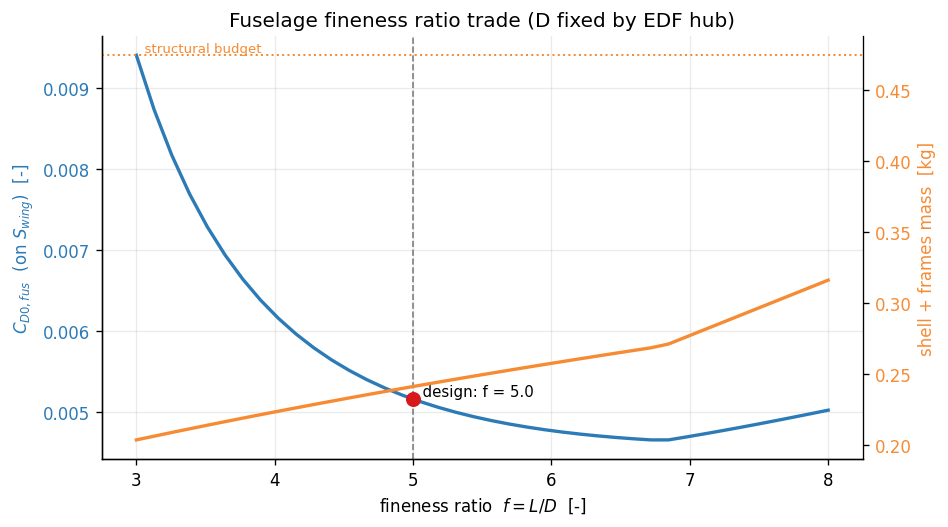

In [5]:
FR_sweep = np.linspace(3.0, 8.0, 40)
cd0_sweep, mshell_sweep = [], []
for fr in FR_sweep:
    p_i = replace(fus_p, fineness_ratio=float(fr))
    f_i = size_fuselage(
        m_battery_kg=result.m_battery_kg, m_payload_kg=result.m_payload_kg,
        m_avionics_kg=result.m_avionics_kg, m_propulsion_kg=result.m_propulsion_kg,
        m_structure_kg=result.m_structure_kg, m_wing_kg=result.m_wing_kg,
        m_misc_kg=result.m_misc_kg,
        R_hub_m=R_hub_m, D_rotor_m=rotor.D_rotor_m, c_vane_m=vanes["c_vane_m"],
        n_vanes=vanes["n_vanes"], S_vane_m2=vanes["S_vane_m2"],
        hinge_xc=vanes["hinge_xc"],
        chord_mean_m=chord_mean_m, V_cruise=mission.V_cruise, rho=env.rho,
        S_wing=S_wing, p=p_i,
    )
    cd0_sweep.append(f_i.CD0_fus)
    mshell_sweep.append(f_i.m_shell_kg)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(FR_sweep, cd0_sweep, color=C[0], lw=2, label=r"$C_{D0,fus}$")
ax1.axvline(fus_p.fineness_ratio, color="gray", ls="--", lw=1)
ax1.plot([fus.fineness], [fus.CD0_fus], "o", color=C[1], ms=8, zorder=5)
ax1.annotate(f"  design: f = {fus.fineness:.1f}", (fus.fineness, fus.CD0_fus),
             fontsize=9, va="bottom")
ax1.set_xlabel("fineness ratio  $f = L/D$  [-]")
ax1.set_ylabel(r"$C_{D0,fus}$  (on $S_{wing}$)  [-]", color=C[0])
ax1.tick_params(axis="y", labelcolor=C[0])

ax2 = ax1.twinx()
ax2.plot(FR_sweep, mshell_sweep, color=C[3], lw=2, label="shell mass")
ax2.axhline(fus.m_struct_budget_kg, color=C[3], ls=":", lw=1.2)
ax2.annotate("  structural budget", (FR_sweep[0], fus.m_struct_budget_kg),
             fontsize=8, color=C[3], va="bottom")
ax2.set_ylabel("shell + frames mass  [kg]", color=C[3])
ax2.tick_params(axis="y", labelcolor=C[3])
ax2.spines.right.set_visible(True)
ax2.grid(False)

ax1.set_title("Fuselage fineness ratio trade (D fixed by EDF hub)")
fig.tight_layout()
fig.savefig(OUT_PATH / "fuselage_drag_trade.png", bbox_inches="tight")
plt.show()

# Section 5 — Drag Budget Check

The conceptual sizing (NB1) assumed a total $C_{D0}$ in
`config/aerodynamics.yaml`.  Now that the two dominant components are actually
designed, verify the assumption still closes:

- wing profile drag from the NB2 airfoil analysis ($C_{d0}$ section, scaled ~1.10
  for the exposed wetted surface ratio),
- fuselage from this notebook's buildup,
- small allowances for duct external surface, vanes, and interference.

---

In [6]:
CD0_budget   = aero.CD0
CD0_wing_est = af["Cd0_section"] * 1.10
CD0_misc     = 0.0025    # duct external + vanes + antennas + interference
CD0_total    = CD0_wing_est + fus.CD0_fus + CD0_misc

print(f"Re_L (cruise)        : {fus.Re_L:.3g}")
print(f"Cf  (turbulent)      : {fus.Cf:.5f}")
print(f"FF  (Raymer)         : {fus.FF:.3f}")
print(f"S_wet fuselage       : {fus.S_wet_m2:.4f} m^2   (S_wet/S_wing = {fus.S_wet_m2/S_wing:.2f})")
print()
print(f"{'CD0 wing (NB2 section x1.10)':<32}: {CD0_wing_est:.5f}")
print(f"{'CD0 fuselage (this notebook)':<32}: {fus.CD0_fus:.5f}")
print(f"{'CD0 duct/vanes/misc allowance':<32}: {CD0_misc:.5f}")
print("-" * 46)
print(f"{'CD0 total (built up)':<32}: {CD0_total:.5f}")
print(f"{'CD0 assumed in sizing (NB1)':<32}: {CD0_budget:.5f}")
margin = (CD0_budget - CD0_total) / CD0_budget * 100
verdict = "CLOSES" if CD0_total <= CD0_budget else "EXCEEDED -- revisit aerodynamics.yaml"
print(f"\nDrag budget {verdict}  (margin {margin:+.1f}%)")

Re_L (cruise)        : 6.8e+05
Cf  (turbulent)      : 0.00481
FF  (Raymer)         : 1.405
S_wet fuselage       : 0.1448 m^2   (S_wet/S_wing = 0.73)

CD0 wing (NB2 section x1.10)    : 0.01386
CD0 fuselage (this notebook)    : 0.00516
CD0 duct/vanes/misc allowance   : 0.00250
----------------------------------------------
CD0 total (built up)            : 0.02152
CD0 assumed in sizing (NB1)     : 0.02500

Drag budget CLOSES  (margin +13.9%)


# Section 6 — Shell Mass Check

Equivalent-monocoque area-density model:

$$
m_{shell} = k_{struct} \cdot \rho_{shell} \cdot t_{shell} \cdot S_{wet}
$$

compared against the structural weight-fraction budget from the mass closure,
**minus** the wing (sized separately by the Raymer formula in NB1):

$$
m_{budget} = m_{structure} - m_{wing}
$$

The duct ring is *not* charged here — shrouds are booked in the propulsion
fraction.

---

In [7]:
print(f"Shell + frames mass (model)   : {fus.m_shell_kg:.3f} kg")
print(f"Structural budget (fraction)  : {fus.m_struct_budget_kg:.3f} kg")
util = fus.m_shell_kg / fus.m_struct_budget_kg * 100
print(f"Budget utilisation            : {util:.0f}%")
if fus.m_shell_kg <= fus.m_struct_budget_kg:
    print("Shell mass CLOSES within the structural fraction.")
else:
    print("Shell mass EXCEEDS budget -- increase fs or thin the laminate.")

Shell + frames mass (model)   : 0.241 kg
Structural budget (fraction)  : 0.475 kg
Budget utilisation            : 51%
Shell mass CLOSES within the structural fraction.


# Section 7 — Longitudinal Layout and CG

Components stack nose-to-tail: **payload → avionics → battery → ESC**, with the
motor + fan at the fan plane in the boattail and the duct ring at the tail.
The propulsion fraction is split 60 / 25 / 15 % between motor+fan / ESC / duct.

The **wing is placed last**: its aerodynamic center goes $SM \cdot MAC$ behind
the all-up CG so the cruise static margin is met by construction:

$$
x_{AC} = x_{CG} + SM \cdot \bar{c}, \qquad x_{LE} = x_{AC} - 0.25\,\bar{c}
$$

Stations from the nose, positive aft;  $x_{body} = -x_s$ (Aetherion FRD).

---

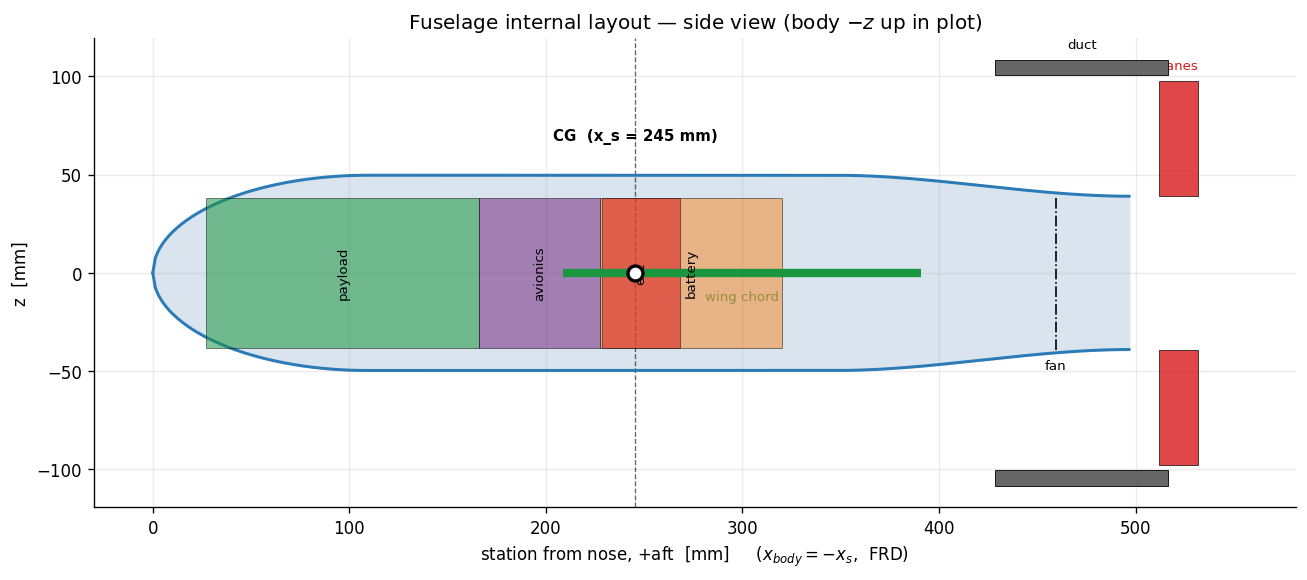

item           mass [kg]   x_cg [mm]
payload            0.500        96.7
avionics           0.152       196.9
battery            0.626       274.0
esc                0.094       248.3
motor_fan          0.225       459.4
duct               0.056       472.6
shell_struct       0.475       223.5
battery_tray       0.015       274.0
control_hw         0.073       516.6
misc               0.160       198.7
wing               0.126       245.3
------------------------------------
CG                 2.502       245.3

Wing LE station : 208.8 mm   (AC at 254.4 mm, SM = 5% MAC)


In [8]:
xs = np.linspace(0.0, fus.L_fus, 400)
rr = np.array([fuselage_radius(x, fus.D_fus, fus.L_fus,
                               fus_p.f_nose, fus_p.f_tail, fus.r_hub) for x in xs])

fig, ax = plt.subplots(figsize=(11, 5))
mm = 1e3

# fuselage outline
ax.fill_between(xs*mm, -rr*mm, rr*mm, color="#d9e4ee", zorder=1)
ax.plot(xs*mm,  rr*mm, color=C[0], lw=1.8, zorder=3)
ax.plot(xs*mm, -rr*mm, color=C[0], lw=1.8, zorder=3)

# internal bays
bay_colors = {"payload": C[2], "avionics": C[4], "battery": C[3], "esc": C[1]}
r_int = fus.D_fus/2 - fus_p.t_shell_m
for it in fus.items:
    if it.name in bay_colors and it.length > 0:
        ax.add_patch(plt.Rectangle((it.x_start*mm, -0.78*r_int*mm),
                                   it.length*mm, 1.56*r_int*mm,
                                   facecolor=bay_colors[it.name], alpha=0.55,
                                   edgecolor="k", lw=0.5, zorder=4))
        ax.annotate(it.name, ((it.x_start + it.length/2)*mm, 0),
                    ha="center", va="center", fontsize=8, rotation=90, zorder=6)

# duct annulus (section view)
x_d0 = (fus.items[5].x_cg - fus.duct_chord/2) * mm     # duct item
for sgn in (+1, -1):
    ax.add_patch(plt.Rectangle((x_d0, sgn*fus.D_duct_inner/2*mm),
                               fus.duct_chord*mm, sgn*fus_p.t_duct_m*mm,
                               facecolor="#666", edgecolor="k", lw=0.5, zorder=4))
ax.annotate("duct", (x_d0 + fus.duct_chord*mm/2, fus.D_duct_outer/2*mm + 6),
            ha="center", fontsize=8)

# control vanes (T/B pair in side view)
for sgn in (+1, -1):
    ax.add_patch(plt.Rectangle(((fus.x_vane - vanes["c_vane_m"]/2)*mm,
                                sgn*vanes["R_hub_m"]*mm),
                               vanes["c_vane_m"]*mm,
                               sgn*(vanes["R_tip_m"]-vanes["R_hub_m"])*mm,
                               facecolor=C[1], alpha=0.8, edgecolor="k",
                               lw=0.5, zorder=4))
ax.annotate("vanes", (fus.x_vane*mm, vanes["R_tip_m"]*mm + 6),
            ha="center", fontsize=8, color=C[1])

# wing chord (side view)
ax.plot([fus.x_wing_LE*mm, (fus.x_wing_LE + chord_mean_m)*mm], [0, 0],
        color=C[2], lw=5, solid_capstyle="butt", zorder=5)
ax.annotate("wing chord", ((fus.x_wing_LE + chord_mean_m/2)*mm, -14),
            ha="center", fontsize=8, color=C[2])

# fan plane
x_fan = fus.items[4].x_cg * mm
ax.plot([x_fan, x_fan], [-fus.r_hub*mm*1.0, fus.r_hub*mm*1.0],
        color="k", ls="-.", lw=1)
ax.annotate("fan", (x_fan, -fus.r_hub*mm - 10), ha="center", fontsize=8)

# CG
ax.plot(fus.x_CG*mm, 0, "o", color="k", ms=9, zorder=7,
        markerfacecolor="w", markeredgewidth=2)
ax.axvline(fus.x_CG*mm, color="k", ls="--", lw=0.8, alpha=0.6)
ax.annotate(f"CG  (x_s = {fus.x_CG*mm:.0f} mm)", (fus.x_CG*mm, fus.D_fus/2*mm + 18),
            ha="center", fontsize=9, fontweight="bold")

ax.set_xlabel(r"station from nose, +aft  [mm]     ($x_{body} = -x_s$,  FRD)")
ax.set_ylabel("z  [mm]")
ax.set_title("Fuselage internal layout — side view (body $-z$ up in plot)")
ax.set_aspect("equal")
ax.set_xlim(-30, (fus.x_vane + 0.06)*mm)
fig.tight_layout()
fig.savefig(OUT_PATH / "fuselage_layout.png", bbox_inches="tight")
plt.show()

print(f"{'item':<14}{'mass [kg]':>10}{'x_cg [mm]':>12}")
for it in fus.items:
    print(f"{it.name:<14}{it.mass_kg:>10.3f}{it.x_cg*1e3:>12.1f}")
print("-" * 36)
print(f"{'CG':<14}{MTOW_kg:>10.3f}{fus.x_CG*1e3:>12.1f}")
print(f"\nWing LE station : {fus.x_wing_LE*1e3:.1f} mm   (AC at {fus.x_wing_AC*1e3:.1f} mm, "
      f"SM = {fus_p.static_margin*100:.0f}% MAC)")

# Section 8 — Control Moment Arm Cross-Check

Notebook 3 sized the jet vanes with an **assumed** CG-to-vane arm
$L_{CG}$.  The layout above gives the *actual* arm.  Since the achievable
control moment is $M = F_{vane} \, L$, the ratio of actual to assumed arm is a
direct **control authority margin** on the NB3 result.

---

In [9]:
L_assumed = vanes["L_CG_m"]
L_actual  = fus.L_vane_arm
factor    = L_actual / L_assumed

print(f"Vane station              : {fus.x_vane*1e3:.1f} mm")
print(f"CG station                : {fus.x_CG*1e3:.1f} mm")
print(f"Actual vane-to-CG arm     : {L_actual*1e3:.1f} mm")
print(f"NB3 assumed arm (L_CG_m)  : {L_assumed*1e3:.1f} mm")
print(f"\nControl authority factor  : x{factor:.2f}")
print(f"Pitch moment available    : {vanes['F_vane_design_N'] * L_actual:.3f} Nm "
      f"(NB3 designed for {vanes['M_pitch_design_Nm']:.3f} Nm)")
if factor >= 1.0:
    print("NB3 vane sizing is CONSERVATIVE -- authority margin is positive.")
else:
    print("WARNING: actual arm SHORTER than assumed -- re-run NB3 with L_CG_m updated.")

Vane station              : 521.6 mm
CG station                : 245.3 mm
Actual vane-to-CG arm     : 276.3 mm
NB3 assumed arm (L_CG_m)  : 120.3 mm

Control authority factor  : x2.30
Pitch moment available    : 0.209 Nm (NB3 designed for 0.182 Nm)
NB3 vane sizing is CONSERVATIVE -- authority margin is positive.


# Section 9 — Output Export

## Output File

$$
\texttt{out/fuselage.yaml}
$$

Handoff interface for downstream use:

- **CAD notebook** — revolve profile parameters, duct geometry, wing/vane
  stations *(all stations from nose, +aft; $x_{body} = -x_s$)*
- **Flight-dynamics setup (Aetherion)** — CG station, static margin, layout
  table for inertia estimation

---

In [10]:
from conceptual_design.fuselage_design import write_fuselage_yaml

write_fuselage_yaml(fus, fus_p, OUT_PATH / "fuselage.yaml")
print(f"Fuselage design written -> {OUT_PATH / 'fuselage.yaml'}")

Fuselage design written -> D:\Dev\vbat-uav-notebooks\out\fuselage.yaml


# Section 10 — Design Summary

In [11]:
bar = "=" * 60
print(bar)
print("  FUSELAGE DESIGN SUMMARY".center(60))
print(bar)
print(f"  {'Max diameter D_fus':<34}: {fus.D_fus*1e3:8.1f} mm")
print(f"  {'Length L_fus':<34}: {fus.L_fus*1e3:8.1f} mm")
print(f"  {'Fineness ratio L/D':<34}: {fus.fineness:8.2f}")
print(f"  {'Active diameter constraint':<34}: {fus.active_constraint:>8s}")
print(f"  {'Nose / mid / tail':<34}: {fus.L_nose*1e3:.0f} / {fus.L_mid*1e3:.0f} / {fus.L_tail*1e3:.0f} mm")
print(f"  {'Tail exit radius (EDF hub)':<34}: {fus.r_hub*1e3:8.1f} mm")
print()
print(f"  {'Enclosed volume':<34}: {fus.V_total_m3*1e3:8.2f} L")
print(f"  {'Bay stack utilisation':<34}: {fus.L_stack_m/fus.L_avail_m*100:8.0f} %")
print(f"  {'Wetted area':<34}: {fus.S_wet_m2:8.4f} m^2")
print(f"  {'CD0 fuselage (on S_wing)':<34}: {fus.CD0_fus:8.5f}")
print(f"  {'Shell + frames mass':<34}: {fus.m_shell_kg:8.3f} kg  "
      f"({fus.m_shell_kg/fus.m_struct_budget_kg*100:.0f}% of budget)")
print()
print(f"  {'CG station (from nose)':<34}: {fus.x_CG*1e3:8.1f} mm")
print(f"  {'Wing LE station':<34}: {fus.x_wing_LE*1e3:8.1f} mm")
print(f"  {'Static margin':<34}: {fus_p.static_margin*100:8.1f} % MAC")
print(f"  {'Vane control arm (actual)':<34}: {fus.L_vane_arm*1e3:8.1f} mm")
print(f"  {'Control authority vs NB3':<34}: x{fus.L_vane_arm/vanes['L_CG_m']:7.2f}")
print()
print(f"  {'Duct chord':<34}: {fus.duct_chord*1e3:8.1f} mm")
print(f"  {'Duct inner / outer diameter':<34}: {fus.D_duct_inner*1e3:.0f} / {fus.D_duct_outer*1e3:.0f} mm")
print(bar)
print("  Axis convention: body FRD (x fwd, y right, z down),")
print("  stations from nose +aft, x_body = -station  [Aetherion]")
print(bar)

                   FUSELAGE DESIGN SUMMARY                  
  Max diameter D_fus                :     99.3 mm
  Length L_fus                      :    496.6 mm
  Fineness ratio L/D                :     5.00
  Active diameter constraint        : packaging
  Nose / mid / tail                 : 109 / 238 / 149 mm
  Tail exit radius (EDF hub)        :     39.0 mm

  Enclosed volume                   :     3.34 L
  Bay stack utilisation             :      100 %
  Wetted area                       :   0.1448 m^2
  CD0 fuselage (on S_wing)          :  0.00516
  Shell + frames mass               :    0.241 kg  (51% of budget)

  CG station (from nose)            :    245.3 mm
  Wing LE station                   :    208.8 mm
  Static margin                     :      5.0 % MAC
  Vane control arm (actual)         :    276.3 mm
  Control authority vs NB3          : x   2.30

  Duct chord                        :     87.8 mm
  Duct inner / outer diameter       : 201 / 217 mm
  Axis convention: b